# MNIST Digit Classification with a CNN

We classify handwritten digits (0–9) from the [MNIST](http://yann.lecun.com/exdb/mnist/) dataset using a Convolutional Neural Network (CNN) built in PyTorch.

**Pipeline:**
1. Load and explore the dataset
2. Understand CNNs — convolution, pooling, and how they learn spatial features
3. Build and train the model
4. Evaluate — accuracy, confusion matrix, per-class metrics
5. Visualise learned filters and failure cases

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. What is a CNN?

A **Convolutional Neural Network** is designed to exploit the spatial structure of images. Unlike a fully-connected network that flattens pixels into a long vector (losing all positional information), a CNN processes images with three key operations:

### Convolution
A small matrix of learnable weights called a **filter** (or kernel) slides across the image. At each position it computes a dot product with the patch of pixels underneath it, producing a single number. Sliding across the whole image produces a **feature map** — a 2D grid showing where that filter's pattern was detected.

- Each filter learns to detect one pattern (an edge, a curve, a corner)
- Multiple filters run in parallel, producing multiple feature maps (the "channels" dimension)
- Weights are **shared** across all positions — the same edge detector works anywhere in the image

```
Input image (28×28)
  └─► Conv layer (32 filters, 3×3)  →  32 feature maps (26×26)
        └─► ReLU activation
              └─► MaxPool (2×2)      →  32 feature maps (13×13)   ← halves spatial size
                    └─► Conv layer (64 filters, 3×3)  →  64 feature maps (11×11)
                          └─► ReLU + MaxPool          →  64 feature maps (5×5)
                                └─► Flatten  →  1600-dim vector
                                      └─► Fully-connected layers  →  10 class scores
```

### Pooling
**MaxPooling** takes the maximum value in each small region (e.g. 2×2), halving the spatial dimensions. This makes the representation smaller and more robust to slight shifts in position.

### Why CNNs work for images
- **Local connectivity** — nearby pixels are related; a filter only looks at a small patch
- **Weight sharing** — the same filter detects the same feature anywhere in the image
- **Hierarchical features** — early layers detect edges; deeper layers combine edges into shapes, then shapes into digit parts

## 2. Load and Explore the Dataset

In [2]:
# Normalise pixels to mean=0.1307, std=0.3081 (MNIST dataset statistics)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

print(f'Train samples : {len(train_ds):,}')
print(f'Test samples  : {len(test_ds):,}')
print(f'Image shape   : {train_ds[0][0].shape}  (channels, height, width)')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 28.7MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 2.99MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 20.7MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 652kB/s]

Train samples : 60,000
Test samples  : 10,000
Image shape   : torch.Size([1, 28, 28])  (channels, height, width)


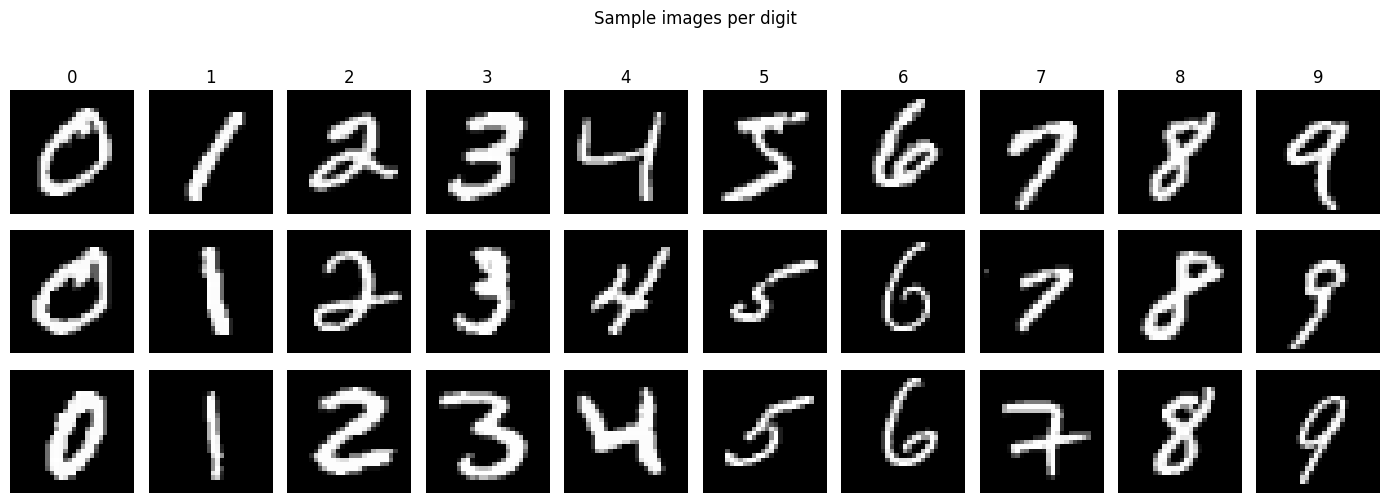

In [3]:
# Show a grid of sample images
fig, axes = plt.subplots(3, 10, figsize=(14, 5))
for digit in range(10):
    indices = [i for i, (_, y) in enumerate(train_ds) if y == digit][:3]
    for row, idx in enumerate(indices):
        img, label = train_ds[idx]
        axes[row, digit].imshow(img.squeeze(), cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit))
plt.suptitle('Sample images per digit', y=1.02)
plt.tight_layout()
plt.show()

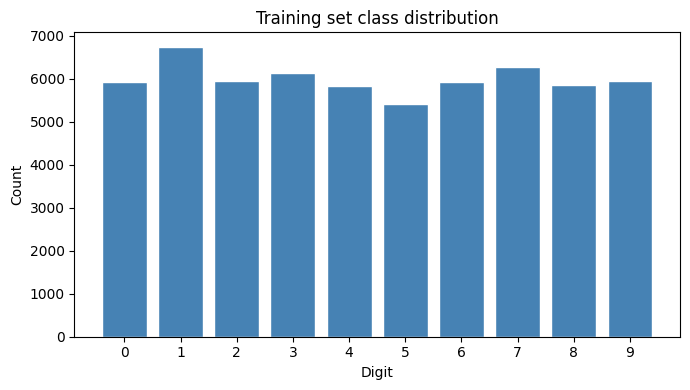

Counts per class: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [4]:
# Class distribution
labels = [y for _, y in train_ds]
counts = np.bincount(labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(10), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(10))
ax.set_title('Training set class distribution')
ax.set_xlabel('Digit')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print('Counts per class:', counts)

## 3. Define the CNN

In [5]:
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 1 input channel (grayscale) → 32 feature maps
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 28×28 → 28×28
        self.pool1 = nn.MaxPool2d(2)                              # 28×28 → 14×14

        # Block 2: 32 → 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 14×14 → 14×14
        self.pool2 = nn.MaxPool2d(2)                              # 14×14 → 7×7

        self.dropout = nn.Dropout(0.25)

        # Fully-connected head: 64 × 7 × 7 = 3136 → 128 → 10
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)   # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)           # raw logits; CrossEntropyLoss applies softmax internally


model = MnistCNN().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

MnistCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,642


## 4. Train the Model

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5
train_losses, train_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch {epoch}/{EPOCHS}  loss: {epoch_loss:.4f}  acc: {epoch_acc:.4f}')

Epoch 1/5  loss: 0.1730  acc: 0.9463
Epoch 2/5  loss: 0.0669  acc: 0.9793
Epoch 3/5  loss: 0.0495  acc: 0.9846
Epoch 4/5  loss: 0.0414  acc: 0.9876
Epoch 5/5  loss: 0.0332  acc: 0.9896


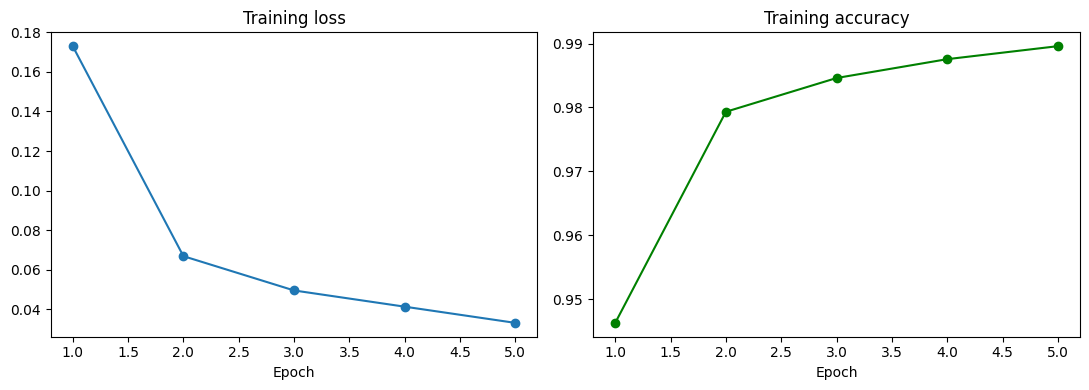

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(range(1, EPOCHS+1), train_accs, marker='o', color='green')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## 5. Evaluate on the Test Set

In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test accuracy: {test_acc:.4f}\n')
print(classification_report(all_labels, all_preds))

Test accuracy: 0.9928

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



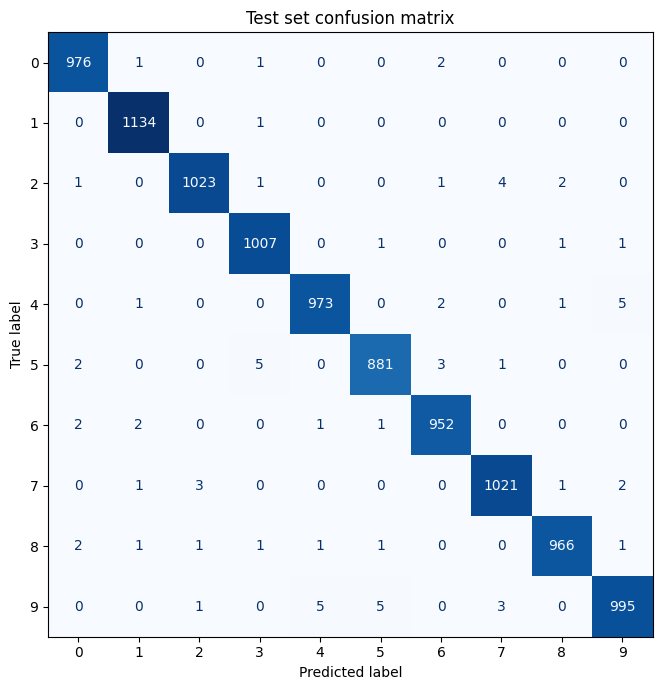

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Test set confusion matrix')
plt.tight_layout()
plt.show()

## 6. Visualise Learned Filters

The first convolutional layer learns 32 filters. Each filter is a 3×3 matrix of weights — visualising them shows what low-level patterns the network looks for (edges, gradients, etc.).

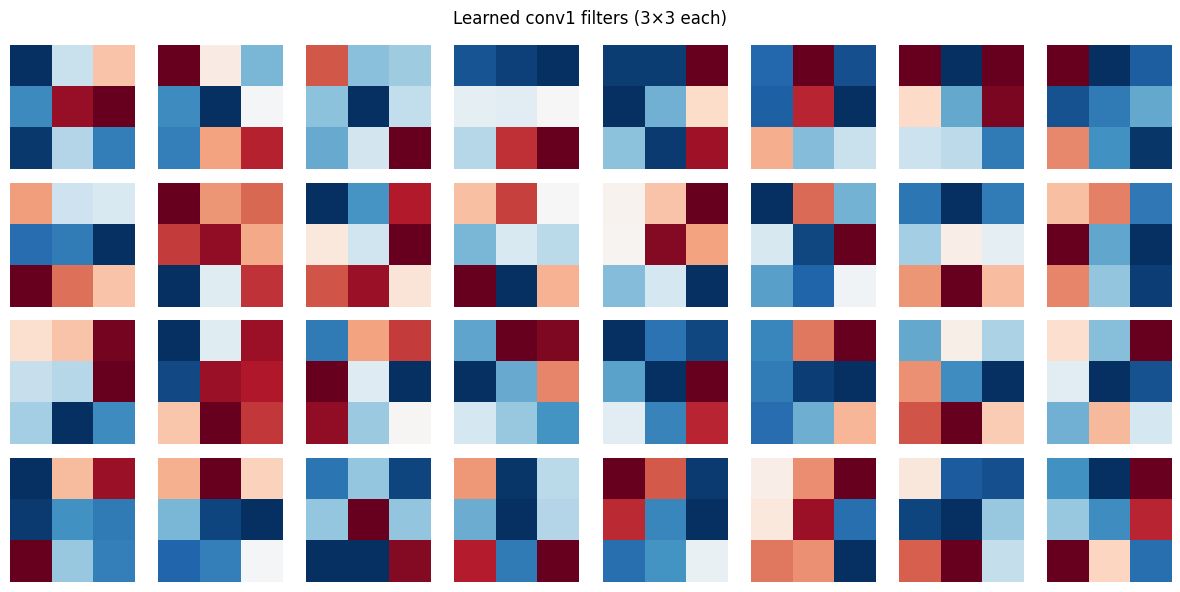

In [10]:
filters = model.conv1.weight.data.cpu()  # shape: (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    f = filters[i, 0]  # single-channel filter
    ax.imshow(f, cmap='RdBu', vmin=f.min(), vmax=f.max())
    ax.axis('off')
plt.suptitle('Learned conv1 filters (3×3 each)')
plt.tight_layout()
plt.show()

## 7. Inspect Misclassified Examples

Looking at the images the model got wrong reveals what kinds of digits are hardest — typically ambiguous handwriting, unusual styles, or digit pairs that look similar (e.g. 4/9, 3/5, 7/1).

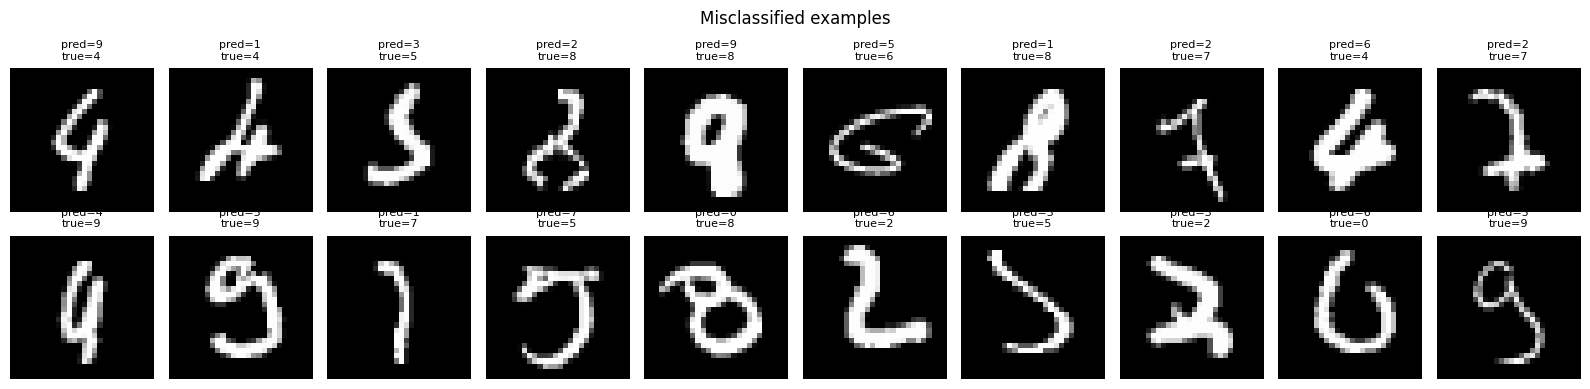

Total misclassified: 72 / 10000


In [11]:
# Collect misclassified examples with their images
model.eval()
wrong_images, wrong_preds, wrong_labels = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        preds = outputs.argmax(dim=1).cpu()
        mask = preds != labels
        wrong_images.extend(images[mask])
        wrong_preds.extend(preds[mask].tolist())
        wrong_labels.extend(labels[mask].tolist())
        if len(wrong_images) >= 20:
            break

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f'pred={wrong_preds[i]}\ntrue={wrong_labels[i]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Misclassified examples')
plt.tight_layout()
plt.show()
print(f'Total misclassified: {(all_preds != all_labels).sum()} / {len(all_labels)}')